In [0]:
# MAGIC #  NOTEBOOK 08 : DÉPLOIEMENT DU MODÈLE
# MAGIC **Objectif** : Déployer le modèle pour faire des prédictions en production
# MAGIC **Contenu** :
# MAGIC - Chargement du modèle depuis Model Registry
# MAGIC - Création d'une fonction de scoring
# MAGIC - Tests sur nouveaux patients (batch predictions)
# MAGIC - Calcul de scores de risque (0-100)
# MAGIC - Sauvegarde des prédictions dans Delta Lake
# MAGIC - Création d'un pipeline automatisé
# MAGIC ##  CELLULE 1 : IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# MLflow

import mlflow
from mlflow.tracking import MlflowClient

# PySpark
from pyspark.sql import functions as F
from pyspark.sql.types import *

print("="*70)
print("IMPORTS RÉUSSIS")
print("="*70)


IMPORTS RÉUSSIS


In [0]:
# MAGIC %md
# MAGIC ##  CELLULE 2 : CHARGEMENT DU MODÈLE EN PRODUCTION

# COMMAND ----------

print("="*70)
print(" CHARGEMENT DU MODÈLE EN PRODUCTION")
print("="*70)

# ============================================================================
# ÉTAPE 1 : CONFIGURATION
# ============================================================================

import mlflow
from mlflow.tracking import MlflowClient

# Nom du modèle (celui que vous avez enregistré)
model_name = "hospital_readmissions_model_mlflow"
alias = "champion"  # Utiliser l'alias champion

print(f"\nConfiguration:")
print(f"   Nom du modèle : {model_name}")
print(f"   Alias : {alias}")

# ============================================================================
# ÉTAPE 2 : CHARGER LE MODÈLE AVEC ALIAS
# ============================================================================

print(f"\n Chargement du modèle avec alias '{alias}'...")

# URI avec alias (recommandé pour production)
model_uri = f"models:/{model_name}@{alias}"
print(f"   URI : {model_uri}")

try:
    # Charger le modèle
    model = mlflow.sklearn.load_model(model_uri)
    print(f" Modèle chargé avec succès")
    
except Exception as e:
    print(f"Erreur : {e}")
    print(f"\n Tentative avec le nom complet Unity Catalog...")
    
    # Essayer avec le nom complet
    model_name_full = f"workspace.default.{model_name}"
    model_uri = f"models:/{model_name_full}@{alias}"
    print(f"   URI : {model_uri}")
    
    model = mlflow.sklearn.load_model(model_uri)
    model_name = model_name_full
    print(f" Modèle chargé avec succès")

# ============================================================================
# ÉTAPE 2B : CRÉER model_sklearn (IMPORTANT POUR LA CELLULE 3)
# ============================================================================

# Le modèle chargé est déjà un modèle sklearn
model_sklearn = model

print(f"\nVariables créées:")
print(f"   • model         : {type(model).__name__}")
print(f"   • model_sklearn : {type(model_sklearn).__name__}")

# ============================================================================
# ÉTAPE 3 : RÉCUPÉRER LES MÉTADONNÉES
# ============================================================================

print(f"\n{'─'*70}")
print(f"MÉTADONNÉES DU MODÈLE")
print(f"{'─'*70}")

client = MlflowClient()

# Récupérer les informations du modèle
try:
    model_details = client.get_registered_model(model_name)
    print(f"   Nom : {model_details.name}")
    
    # Alias
    if hasattr(model_details, 'aliases') and model_details.aliases:
        print(f"   Alias : {list(model_details.aliases.keys())}")
    
    # Récupérer la version correspondant à l'alias
    if hasattr(model_details, 'aliases') and alias in model_details.aliases:
        version_number = model_details.aliases[alias]
        print(f"   Version (alias {alias}) : {version_number}")
        
        # Récupérer les détails de cette version
        model_version = client.get_model_version(model_name, version_number)
        run_id = model_version.run_id
        
        print(f"   Run ID : {run_id}")
        
        # Description
        if model_version.description:
            desc = model_version.description[:150]
            print(f"   Description : {desc}{'...' if len(model_version.description) > 150 else ''}")
        
        # Récupérer les métriques du run
        try:
            run = mlflow.get_run(run_id)
            if run.data.metrics:
                print(f"\nMétriques du modèle :")
                # Afficher les métriques clés
                key_metrics = ['auc_roc', 'recall', 'precision', 'f1', 'accuracy']
                for metric in key_metrics:
                    if metric in run.data.metrics:
                        print(f"      • {metric:<15} : {run.data.metrics[metric]:.4f}")
        except Exception as e:
            print(f" Métriques non disponibles : {e}")
            
except Exception as e:
    print(f" Impossible de récupérer les métadonnées : {e}")
    version_number = "Unknown"
    run_id = "Unknown"

# ============================================================================
# ÉTAPE 4 : VÉRIFIER LE MODÈLE ET LA SIGNATURE
# ============================================================================

print(f"\n{'─'*70}")
print(f"VÉRIFICATION DU MODÈLE")
print(f"{'─'*70}")

print(f"   Type : {type(model).__name__}")

# Vérifier si c'est un Pipeline
if hasattr(model, 'named_steps'):
    print(f"   Structure : Pipeline sklearn")
    print(f"   Étapes : {list(model.named_steps.keys())}")
    
    # Extraire le modèle final du pipeline
    if 'classifier' in model.named_steps:
        final_model = model.named_steps['classifier']
    elif 'model' in model.named_steps:
        final_model = model.named_steps['model']
    else:
        final_model = model.steps[-1][1]
    
    print(f"   Modèle final : {type(final_model).__name__}")

# Vérifier que predict_proba est disponible
if hasattr(model_sklearn, 'predict_proba'):
    print(f"predict_proba disponible")
else:
    print(f" predict_proba NON disponible - vérifier le modèle")

# Récupérer la signature
try:
    model_info = mlflow.models.get_model_info(model_uri)
    if model_info.signature:
        sig = model_info.signature
        # Inputs
        if sig.inputs:
            inputs_list = sig.inputs.to_dict()
            if isinstance(inputs_list, list):
                n_features = len(inputs_list)
                print(f"\n Features attendues : {n_features}")
                print(f"   Exemples :")
                for inp in inputs_list[:5]:
                    print(f"      • {inp.get('name', 'N/A')} ({inp.get('type', 'N/A')})")
                if n_features > 5:
                    print(f"      ... et {n_features - 5} autres")
        
        # Outputs
        if sig.outputs:
            outputs_list = sig.outputs.to_dict()
            if isinstance(outputs_list, list):
                print(f"\n Outputs :")
                for out in outputs_list:
                    print(f"      • {out.get('name', 'N/A')} ({out.get('type', 'N/A')})")
    else:
        print(f"  Pas de signature disponible")
        
except Exception as e:
    print(f"  Impossible de récupérer la signature : {e}")

# ============================================================================
# ÉTAPE 5 : SAUVEGARDER LES VARIABLES GLOBALES
# ============================================================================

print(f"\n{'='*70}")
print(f"MODÈLE PRÊT POUR LES PRÉDICTIONS")
print(f"{'='*70}")

# Variables globales pour les cellules suivantes
MODEL_VERSION = version_number
MODEL_NAME = model_name
MODEL_URI = model_uri
MODEL_ALIAS = alias

print(f"\n Variables disponibles pour les cellules suivantes :")
print(f"   • model           : Le modèle chargé (MLflow wrapper)")
print(f"   • model_sklearn   : Le modèle sklearn sous-jacent (POUR PREDICT_PROBA)")
print(f"   • MODEL_NAME      : '{MODEL_NAME}'")
print(f"   • MODEL_VERSION   : {MODEL_VERSION}")
print(f"   • MODEL_ALIAS     : '{MODEL_ALIAS}'")
print(f"   • MODEL_URI       : '{MODEL_URI}'")

print(f"\nmodel_sklearn.predict_proba existe : {hasattr(model_sklearn, 'predict_proba')}")
print(f"   • Type de model_sklearn : {type(model_sklearn).__name__}")

# COMMAND ----------

 CHARGEMENT DU MODÈLE EN PRODUCTION

Configuration:
   Nom du modèle : hospital_readmissions_model_mlflow
   Alias : champion

 Chargement du modèle avec alias 'champion'...
   URI : models:/hospital_readmissions_model_mlflow@champion
 Modèle chargé avec succès

Variables créées:
   • model         : Pipeline
   • model_sklearn : Pipeline

──────────────────────────────────────────────────────────────────────
MÉTADONNÉES DU MODÈLE
──────────────────────────────────────────────────────────────────────
   Nom : workspace.default.hospital_readmissions_model_mlflow
   Alias : ['champion']
   Version (alias champion) : 5
   Run ID : 167c5b3495194bdb863cf38405ec55d0
   Description : MODÈLE DE PRÉDICTION DES RÉADMISSIONS HOSPITALIÈRES

PERFORMANCE :
- Type de modèle : Logistic Regression
- AUC-ROC : 0.6458
- AUC-PR : 0.3593
- F1-Sc...

Métriques du modèle :
      • auc_roc         : 0.6458
      • recall          : 0.9916
      • precision       : 0.2501
      • f1              : 0.3994
     

In [0]:
# MAGIC %md
# MAGIC ##  CELLULE 3 : FONCTION DE SCORING (VRAIES PROBABILITÉS)

# COMMAND ----------

print("="*70)
print("CRÉATION DE LA FONCTION DE SCORING")
print("="*70)

# ============================================================================
# FONCTION PRINCIPALE DE SCORING
# ============================================================================

def score_patients(patient_data_df):
    """
    Fonction de scoring pour prédire le risque de réadmission
    
    Args:
        patient_data_df: DataFrame pandas avec les features des patients
                        Colonnes OBLIGATOIRES (9 features):
                        - duree_sejour_category (str)
                        - charlson_category (str)
                        - medicaments_category (str)
                        - gravite_category (str)
                        - age_category (str)
                        - maladie_renale (bool)
                        - admission_urgence (bool)
                        - diabete (bool)
                        - depression (bool)
    
    Returns:
        DataFrame pandas avec colonnes:
        - prediction: Prédiction binaire (0/1)
        - risk_probability: Probabilité de réadmission (0-1)
        - risk_score_100: Score de risque (0-100)
        - risk_category: Catégorie de risque (Faible/Moyen/Élevé)
    """
    
    if patient_data_df.empty:
        raise ValueError("Le DataFrame est vide")
    
    n_patients = len(patient_data_df)
    print(f"\n Scoring de {n_patients} patient(s)...")
    
    # ========================================================================
    # MÉTHODE 1 : Accéder directement au modèle sklearn (RECOMMANDÉ)
    # ========================================================================
    
    risk_proba = None
    binary_predictions = None
    method_used = None
    
    try:
        print(f" Méthode 1: Accès direct au modèle sklearn...")
        
        # Vérifier si model_sklearn existe (de la cellule précédente)
        if 'model_sklearn' in globals():
            sklearn_model = model_sklearn
            print(f"   Utilisation de model_sklearn global")
        elif hasattr(model, '_model_impl'):
            print(f"   Extraction depuis model._model_impl...")
            python_model = model._model_impl.python_model
            
            if hasattr(python_model, 'model'):
                sklearn_model = python_model.model
            elif hasattr(python_model, 'predict_proba'):
                sklearn_model = python_model
            else:
                raise AttributeError("Modèle sklearn non trouvé")
        else:
            raise AttributeError("Impossible d'accéder au modèle sklearn")
        
        print(f"   Modèle sklearn: {type(sklearn_model).__name__}")
        
        # Vérifier predict_proba
        if not hasattr(sklearn_model, 'predict_proba'):
            raise AttributeError(f"predict_proba non disponible sur {type(sklearn_model).__name__}")
        
        # OBTENIR LES VRAIES PROBABILITÉS
        print(f"   Appel de predict_proba...")
        probas = sklearn_model.predict_proba(patient_data_df)
        binary_predictions = sklearn_model.predict(patient_data_df)
        
        print(f"   Probabilités extraites via predict_proba")
        print(f"   Shape des probabilités: {probas.shape}")
        
        # Extraire probabilité de la classe 1 (réadmission)
        if probas.shape[1] >= 2:
            risk_proba = probas[:, 1]
        else:
            risk_proba = probas[:, 0]
        
        method_used = "sklearn_direct"
        print(f"  Méthode 1 RÉUSSIE")
        
    except Exception as e:
        print(f"  Méthode 1 échouée: {str(e)}")
        
        # ====================================================================
        # MÉTHODE 2 : Via MLflow pyfunc avec pandas DataFrame
        # ====================================================================
        
        try:
            print(f"\n  Méthode 2: Via MLflow pyfunc...")
            
            # Convertir explicitement en pandas DataFrame si nécessaire
            if not isinstance(patient_data_df, pd.DataFrame):
                patient_data_df = pd.DataFrame(patient_data_df)
            
            # S'assurer que les types sont corrects
            patient_data_df_typed = patient_data_df.copy()
            
            # Forcer les types pour les colonnes catégorielles
            categorical_cols = ['duree_sejour_category', 'charlson_category', 
                              'medicaments_category', 'gravite_category', 'age_category']
            for col in categorical_cols:
                if col in patient_data_df_typed.columns:
                    patient_data_df_typed[col] = patient_data_df_typed[col].astype(str)
            
            # Forcer les types pour les colonnes booléennes
            boolean_cols = ['maladie_renale', 'admission_urgence', 'diabete', 'depression']
            for col in boolean_cols:
                if col in patient_data_df_typed.columns:
                    patient_data_df_typed[col] = patient_data_df_typed[col].astype(bool)
            
            print(f"    Input DataFrame shape: {patient_data_df_typed.shape}")
            
            # Prédire avec le modèle MLflow
            predictions_result = model.predict(patient_data_df_typed)
            
            print(f"   Type de résultat: {type(predictions_result)}")
            
            # Cas 1: DataFrame avec colonnes structurées
            if isinstance(predictions_result, pd.DataFrame):
                print(f"    Colonnes retournées: {predictions_result.columns.tolist()}")
                
                # Extraire les probabilités
                if 'probability_class_1' in predictions_result.columns:
                    risk_proba = predictions_result['probability_class_1'].values
                    print(f"    Probabilités extraites de 'probability_class_1'")
                elif 'probability_class_0' in predictions_result.columns:
                    risk_proba = 1 - predictions_result['probability_class_0'].values
                    print(f"    Probabilités calculées depuis 'probability_class_0'")
                else:
                    raise ValueError(f"Colonnes de probabilité non trouvées")
                
                # Extraire les prédictions
                if 'prediction' in predictions_result.columns:
                    binary_predictions = predictions_result['prediction'].values
                else:
                    binary_predictions = (risk_proba >= 0.5).astype(int)
                
                method_used = "mlflow_dataframe"
            
            # Cas 2: Array numpy
            elif isinstance(predictions_result, np.ndarray):
                print(f"    Shape du résultat: {predictions_result.shape}")
                
                # Si shape (n, 3), ce sont [prediction, proba_0, proba_1]
                if len(predictions_result.shape) > 1 and predictions_result.shape[1] == 3:
                    binary_predictions = predictions_result[:, 0].astype(int)
                    risk_proba = predictions_result[:, 2]  # proba classe 1
                    method_used = "mlflow_array_3cols"
                
                # Si shape (n, 2), ce sont [proba_0, proba_1]
                elif len(predictions_result.shape) > 1 and predictions_result.shape[1] == 2:
                    risk_proba = predictions_result[:, 1]
                    binary_predictions = (risk_proba >= 0.5).astype(int)
                    method_used = "mlflow_array_2cols"
                
                else:
                    raise ValueError(f"Format array non reconnu: shape {predictions_result.shape}")
            
            else:
                raise ValueError(f"Type de résultat non supporté: {type(predictions_result)}")
            
            print(f"    Méthode 2 RÉUSSIE")
        
        except Exception as e2:
            print(f"    Méthode 2 échouée: {str(e2)}")
            import traceback
            traceback.print_exc()
            
            # Les deux méthodes ont échoué
            raise RuntimeError(
                "Impossible d'obtenir les probabilités du modèle.\n"
                "Méthode 1 (sklearn direct) échouée.\n"
                "Méthode 2 (MLflow pyfunc) échouée.\n"
               
            )
    
    # ========================================================================
    # VÉRIFICATION QUE LES PROBABILITÉS ONT ÉTÉ OBTENUES
    # ========================================================================
    
    if risk_proba is None or binary_predictions is None:
        raise RuntimeError(
            " ERREUR CRITIQUE: Les probabilités n'ont pas pu être extraites.\n"
            "Vérifiez que:\n"
            "  1. Le modèle a été chargé correctement (cellule 1)\n"
            "  2. model_sklearn existe dans les variables globales\n"
            "  3. Le modèle supporte predict_proba()"
        )
    
    # ========================================================================
    # CALCUL DES SCORES ET CATÉGORIES
    # ========================================================================
    
    # Convertir en score 0-100
    risk_score_100 = risk_proba * 100
    
    # Catégoriser le risque
    def categorize_risk(score):
        if score < 40:
            return 'Faible'
        elif score < 70:
            return 'Moyen'
        else:
            return 'Élevé'
    
    risk_categories = [categorize_risk(s) for s in risk_score_100]
    
    # Créer le DataFrame de résultats
    results = pd.DataFrame({
        'prediction': binary_predictions,
        'risk_probability': risk_proba,
        'risk_score_100': risk_score_100,
        'risk_category': risk_categories
    })
    
    # ========================================================================
    # AFFICHAGE DES STATISTIQUES
    # ========================================================================
    
    print(f"\n    Méthode utilisée: {method_used}")
    print(f"\n    Statistiques des scores:")
    print(f"      • Score moyen : {risk_score_100.mean():.1f}/100")
    print(f"      • Score min   : {risk_score_100.min():.1f}/100")
    print(f"      • Score max   : {risk_score_100.max():.1f}/100")
    print(f"      • Écart-type  : {risk_score_100.std():.1f}")
    
    # Distribution par catégorie
    cat_counts = results['risk_category'].value_counts()
    print(f"\n    Distribution par catégorie de risque:")
    for cat in ['Faible', 'Moyen', 'Élevé']:
        if cat in cat_counts:
            count = cat_counts[cat]
            pct = (count / n_patients) * 100
            print(f"      • {cat:<10} : {count:3d} ({pct:5.1f}%)")
    
    # Distribution des prédictions
    pred_counts = results['prediction'].value_counts()
    print(f"\n    Prédictions binaires:")
    print(f"      • Non réadmis (0) : {pred_counts.get(0, 0):3d} ({pred_counts.get(0, 0)/n_patients*100:5.1f}%)")
    print(f"      • Réadmis (1)     : {pred_counts.get(1, 0):3d} ({pred_counts.get(1, 0)/n_patients*100:5.1f}%)")
    
    return results
# FONCTIONS AUXILIAIRES
# ======================================================================
def create_test_patient(
    duree_sejour='2-7 jours',
    charlson='Élevé (≥3)',
    medicaments='15-30 médicaments',
    gravite='Élevé (≥3)',
    age='60-79 ans',
    maladie_renale=True,
    admission_urgence=True,
    diabete=True,
    depression=False
):
    """Créer un patient test avec les 9 features obligatoires"""
    return pd.DataFrame({
        'duree_sejour_category': [duree_sejour],
        'charlson_category': [charlson],
        'medicaments_category': [medicaments],
        'gravite_category': [gravite],
        'age_category': [age],
        'maladie_renale': [maladie_renale],
        'admission_urgence': [admission_urgence],
        'diabete': [diabete],
        'depression': [depression]
    })

def score_patients_with_details(patient_data_df):
    """Version étendue qui retourne les prédictions + données originales"""
    scores_df = score_patients(patient_data_df)
    result_df = pd.concat([patient_data_df.reset_index(drop=True), 
                           scores_df.reset_index(drop=True)], 
                          axis=1)
    return result_df

# ============================================================================
# TESTS
# ============================================================================

print(f"\n{'─'*70}")
print(f" TEST DE LA FONCTION")
print(f"{'─'*70}")

# Test 1: Patient à HAUT RISQUE
print(f"\n{'━'*70}")
print(f"TEST 1 : PATIENT À HAUT RISQUE")
print(f"{'━'*70}")

test_patient_high = create_test_patient(
    duree_sejour='15+ jours',
    charlson='Élevé (≥3)',
    medicaments='31+ médicaments',
    gravite='Élevé (≥3)',
    age='80+ ans',
    maladie_renale=True,
    admission_urgence=True,
    diabete=True,
    depression=True
)

print(f"\n Profil du patient:")
for col, val in test_patient_high.iloc[0].items():
    print(f"   • {col:<25} : {val}")

try:
    result_high = score_patients(test_patient_high)
    
    print(f"\n RÉSULTAT DU SCORING:")
    print(f"   • Prédiction          : {'RÉADMIS' if result_high['prediction'].iloc[0] == 1 else 'NON RÉADMIS'}")
    print(f"   • Probabilité         : {result_high['risk_probability'].iloc[0]:.1%}")
    print(f"   • Score (0-100)       : {result_high['risk_score_100'].iloc[0]:.1f}/100")
    print(f"   • Catégorie de risque : {result_high['risk_category'].iloc[0]}")

except Exception as e:
    print(f"\n ERREUR lors du test : {e}")
    print(f"\n Action requise:")
    print(f"   → Vérifiez que la cellule 1 (chargement du modèle) a été exécutée")
    print(f"   → Vérifiez que model_sklearn est défini")

print(f"\n{'='*70}")
print(f"FONCTION DE SCORING DÉFINIE")
print(f"{'='*70}")

CRÉATION DE LA FONCTION DE SCORING

──────────────────────────────────────────────────────────────────────
 TEST DE LA FONCTION
──────────────────────────────────────────────────────────────────────

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TEST 1 : PATIENT À HAUT RISQUE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 Profil du patient:
   • duree_sejour_category     : 15+ jours
   • charlson_category         : Élevé (≥3)
   • medicaments_category      : 31+ médicaments
   • gravite_category          : Élevé (≥3)
   • age_category              : 80+ ans
   • maladie_renale            : True
   • admission_urgence         : True
   • diabete                   : True
   • depression                : True

 Scoring de 1 patient(s)...
 Méthode 1: Accès direct au modèle sklearn...
   Utilisation de model_sklearn global
   Modèle sklearn: Pipeline
   Appel de predict_proba...
   Probabilités extraites via predict_proba
   Shape des proba

In [0]:
# MAGIC %md
# MAGIC ## CELLULE 4 : TEST SUR NOUVEAUX PATIENTS (Batch Scoring - ROBUSTE)

# COMMAND ----------

print("="*70)
print(" TEST SUR NOUVEAUX PATIENTS (BATCH SCORING)")
print("="*70)

# ============================================================================
#  CHARGER LES DONNÉES
# ============================================================================

table_name = "workspace.default.hospital_readmissions_modeling"
df_spark = spark.table(table_name)
df_pd = df_spark.toPandas()

print(f" Données chargées : {df_pd.shape[0]} lignes")

# ============================================================================
# DÉFINITION DES FEATURES ATTENDUES PAR LE MODÈLE
# ============================================================================

required_features = [
    'duree_sejour_category',
    'charlson_category',
    'medicaments_category',
    'gravite_category',
    'age_category',        # peut être absente
    'maladie_renale',
    'admission_urgence',
    'diabete',             # peut être absente
    'depression'
]

target_col = 'readmission_30j'
id_col = 'patient_id'

# ============================================================================
# CORRECTION DES COLONNES MANQUANTES
# ============================================================================

# ---- age_category ----
if 'age_category' not in df_pd.columns:
    print(" 'age_category' manquante → reconstruction")

    if 'age' in df_pd.columns:
        df_pd['age_category'] = pd.cut(
            df_pd['age'],
            bins=[0, 40, 60, 80, 200],
            labels=['<40 ans', '40-59 ans', '60-79 ans', '80+ ans'],
            right=False
        )
    else:
        # Valeur par défaut clinique
        df_pd['age_category'] = '60-79 ans'
        print("   → Valeur par défaut utilisée : '60-79 ans'")

# ---- diabete ----
if 'diabete' not in df_pd.columns:
    print("  'diabete' manquante → valeur par défaut")
    df_pd['diabete'] = False

# ============================================================================
#  VÉRIFICATION FINALE
# ============================================================================

missing_cols = [c for c in required_features if c not in df_pd.columns]
if missing_cols:
    raise ValueError(f"Colonnes toujours manquantes : {missing_cols}")

print(" Toutes les colonnes requises sont disponibles")

# ============================================================================
# SIMULATION DE NOUVEAUX PATIENTS
# ============================================================================

n_new_patients = 100
np.random.seed(42)

sample_df = df_pd.sample(
    n=n_new_patients,
    random_state=42
).reset_index(drop=True)

X_new_patients = sample_df[required_features]
patient_ids_new = sample_df[id_col]
y_true_new = sample_df[target_col].astype(int)

print(f"Simulation de {n_new_patients} nouveaux patients")


# SCORING ============================================================================

print(f"\n Calcul des scores de risque...")

predictions = score_patients(X_new_patients)

# ============================================================================
#  AJOUT MÉTADONNÉES
# ============================================================================

predictions['patient_id'] = patient_ids_new.values
predictions['readmission_reelle'] = y_true_new.values
predictions['scoring_date'] = datetime.now()

predictions = predictions[
    [
        'patient_id',
        'risk_probability',
        'risk_score_100',
        'risk_category',
        'prediction',
        'readmission_reelle',
        'scoring_date'
    ]
]

print(f"\n Scoring terminé")

# ============================================================================
#  AFFICHAGE
# ============================================================================

display(
    predictions.head(20)
    .style
    .format({
        'risk_probability': '{:.2%}',
        'risk_score_100': '{:.1f}'
    })
    .background_gradient(
        subset=['risk_score_100'],
        cmap='RdYlGn_r',
        vmin=0,
        vmax=100
    )
)

# ============================================================================
#  STATISTIQUES
# ============================================================================

print(f"\nSTATISTIQUES DES PRÉDICTIONS")
print(f"{'─'*70}")
print(f"   Score moyen  : {predictions['risk_score_100'].mean():.1f}/100")
print(f"   Score médian : {predictions['risk_score_100'].median():.1f}/100")
print(f"   Score min    : {predictions['risk_score_100'].min():.1f}/100")
print(f"   Score max    : {predictions['risk_score_100'].max():.1f}/100")

print(f"\n RÉPARTITION PAR CATÉGORIE")
category_counts = predictions['risk_category'].value_counts()
for category, count in category_counts.items():
    pct = count / len(predictions) * 100
    print(f"   {category:<10} : {count:>3} patients ({pct:>5.1f}%)")

print("="*70)
print(" CELLULE 4 EXÉCUTÉE AVEC SUCCÈS")
print("="*70)


 TEST SUR NOUVEAUX PATIENTS (BATCH SCORING)
 Données chargées : 69750 lignes
 'age_category' manquante → reconstruction
   → Valeur par défaut utilisée : '60-79 ans'
  'diabete' manquante → valeur par défaut
 Toutes les colonnes requises sont disponibles
Simulation de 100 nouveaux patients

 Calcul des scores de risque...

 Scoring de 100 patient(s)...
 Méthode 1: Accès direct au modèle sklearn...
   Utilisation de model_sklearn global
   Modèle sklearn: Pipeline
   Appel de predict_proba...
   Probabilités extraites via predict_proba
   Shape des probabilités: (100, 2)
  Méthode 1 RÉUSSIE

    Méthode utilisée: sklearn_direct

    Statistiques des scores:
      • Score moyen : 46.9/100
      • Score min   : 29.6/100
      • Score max   : 71.7/100
      • Écart-type  : 11.5

    Distribution par catégorie de risque:
      • Faible     :  36 ( 36.0%)
      • Moyen      :  61 ( 61.0%)
      • Élevé      :   3 (  3.0%)

    Prédictions binaires:
      • Non réadmis (0) :  60 ( 60.0%)
    

,patient_id,risk_probability,risk_score_100,risk_category,prediction,readmission_reelle,scoring_date
0,PAT_004411,55.10%,55.1,Moyen,1,0,2026-01-21 13:51:04.426492
1,PAT_061311,40.80%,40.8,Moyen,0,1,2026-01-21 13:51:04.426492
2,PAT_069370,66.83%,66.8,Moyen,1,0,2026-01-21 13:51:04.426492
3,PAT_001180,44.23%,44.2,Moyen,0,0,2026-01-21 13:51:04.426492
4,PAT_020969,35.06%,35.1,Faible,0,1,2026-01-21 13:51:04.426492
5,PAT_003757,46.88%,46.9,Moyen,0,0,2026-01-21 13:51:04.426492
6,PAT_017554,38.99%,39.0,Faible,0,0,2026-01-21 13:51:04.426492
7,PAT_042917,65.36%,65.4,Moyen,1,1,2026-01-21 13:51:04.426492
8,PAT_036924,58.37%,58.4,Moyen,1,1,2026-01-21 13:51:04.426492
9,PAT_008588,30.63%,30.6,Faible,0,0,2026-01-21 13:51:04.426492



STATISTIQUES DES PRÉDICTIONS
──────────────────────────────────────────────────────────────────────
   Score moyen  : 46.9/100
   Score médian : 44.2/100
   Score min    : 29.6/100
   Score max    : 71.7/100

 RÉPARTITION PAR CATÉGORIE
   Moyen      :  61 patients ( 61.0%)
   Faible     :  36 patients ( 36.0%)
   Élevé      :   3 patients (  3.0%)
 CELLULE 4 EXÉCUTÉE AVEC SUCCÈS


 VALIDATION DES PRÉDICTIONS

 PERFORMANCE SUR LES 100 NOUVEAUX PATIENTS :
──────────────────────────────────────────────────────────────────────
   AUC-ROC    : 0.4873
   Accuracy   : 0.5500
   Precision  : 0.2000
   Recall     : 0.3810
   F1-Score   : 0.2623
──────────────────────────────────────────────────────────────────────

 Matrice de confusion :
   TN:  47  |  FP:  32
   FN:  13  |  TP:   8


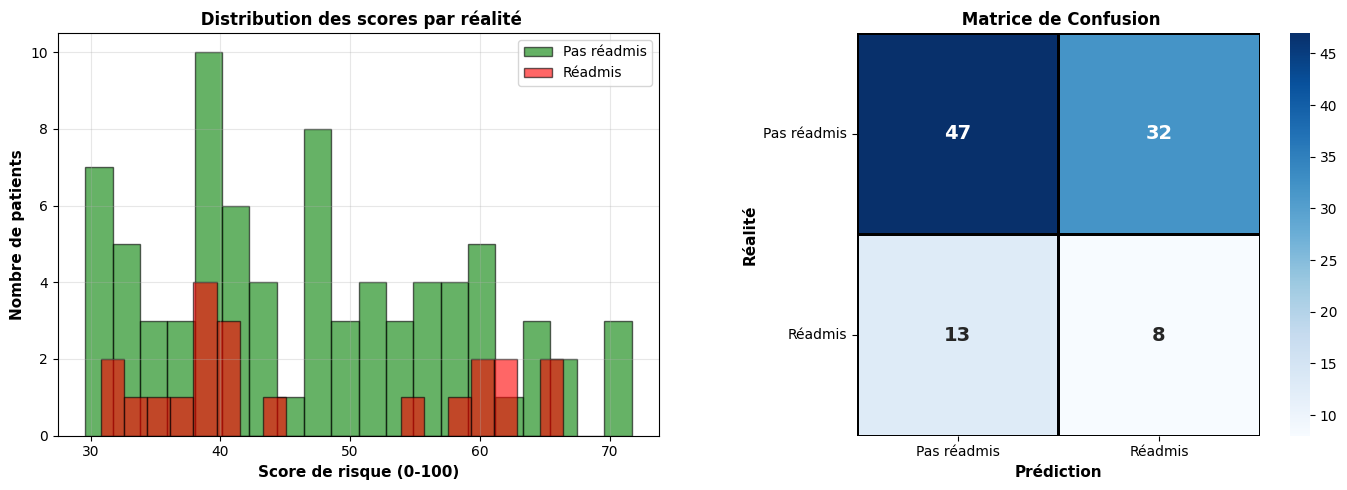


 Visualisations sauvegardées : /Volumes/workspace/default/amdy_hopitalisation_data/deployment/deployment_validation.png


In [0]:
# MAGIC ##  CELLULE 5 : VALIDATION DES PRÉDICTIONS

# COMMAND ----------

print("="*70)
print(" VALIDATION DES PRÉDICTIONS")
print("="*70)

from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import os

# Vérifier que les colonnes nécessaires existent
required_cols = ['risk_probability', 'readmission_reelle', 'risk_score_100']
for col in required_cols:
    if col not in predictions.columns:
        raise ValueError(f" Colonne manquante : {col}")

# Prédictions binaires (seuil 0.5)
y_pred_binary = (predictions['risk_probability'] >= 0.5).astype(int)
y_true = predictions['readmission_reelle']

# Métriques
auc = roc_auc_score(y_true, predictions['risk_probability'])
acc = accuracy_score(y_true, y_pred_binary)
precision = precision_score(y_true, y_pred_binary)
recall = recall_score(y_true, y_pred_binary)
f1 = f1_score(y_true, y_pred_binary)

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred_binary)
tn, fp, fn, tp = cm.ravel()

print(f"\n PERFORMANCE SUR LES {len(predictions)} NOUVEAUX PATIENTS :")
print(f"{'─'*70}")
print(f"   AUC-ROC    : {auc:.4f}")
print(f"   Accuracy   : {acc:.4f}")
print(f"   Precision  : {precision:.4f}")
print(f"   Recall     : {recall:.4f}")
print(f"   F1-Score   : {f1:.4f}")
print(f"{'─'*70}")

print(f"\n Matrice de confusion :")
print(f"   TN: {tn:>3}  |  FP: {fp:>3}")
print(f"   FN: {fn:>3}  |  TP: {tp:>3}")

# ========================================
# VISUALISATIONS
# ========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des scores
ax1 = axes[0]
predictions_readmitted = predictions[predictions['readmission_reelle'] == 1]
predictions_not_readmitted = predictions[predictions['readmission_reelle'] == 0]

ax1.hist(predictions_not_readmitted['risk_score_100'], bins=20, alpha=0.6, label='Pas réadmis', color='green', edgecolor='black')
ax1.hist(predictions_readmitted['risk_score_100'], bins=20, alpha=0.6, label='Réadmis', color='red', edgecolor='black')
ax1.set_xlabel('Score de risque (0-100)', fontweight='bold', fontsize=11)
ax1.set_ylabel('Nombre de patients', fontweight='bold', fontsize=11)
ax1.set_title(' Distribution des scores par réalité', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Matrice de confusion heatmap
ax2 = axes[1]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, square=True, cbar=True,
            annot_kws={'fontsize': 14, 'fontweight': 'bold'}, linewidths=2, linecolor='black')
ax2.set_xlabel('Prédiction', fontweight='bold', fontsize=11)
ax2.set_ylabel('Réalité', fontweight='bold', fontsize=11)
ax2.set_title(' Matrice de Confusion', fontsize=12, fontweight='bold')
ax2.set_xticklabels(['Pas réadmis', 'Réadmis'])
ax2.set_yticklabels(['Pas réadmis', 'Réadmis'], rotation=0)

plt.tight_layout()

# Sauvegarde sécurisée
save_dir = '/Volumes/workspace/default/amdy_hopitalisation_data/deployment'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'deployment_validation.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Visualisations sauvegardées : {save_path}")
print("="*70)


In [0]:
# MAGIC ##  CELLULE 6 : IDENTIFICATION PATIENTS À HAUT RISQUE

print("="*70)
print(" IDENTIFICATION DES PATIENTS À HAUT RISQUE")
print("="*70)

# Vérification que les colonnes nécessaires existent
required_cols = ['risk_category', 'risk_score_100', 'risk_probability', 'readmission_reelle']
missing_cols = [col for col in required_cols if col not in predictions.columns]
if missing_cols:
    raise ValueError(f" Colonnes manquantes dans 'predictions' : {missing_cols}")

# Filtrer patients à haut risque (catégorie 'Élevé' ou score > 70)
high_risk_patients = predictions[predictions['risk_category'] == 'Élevé'].copy()
high_risk_patients = high_risk_patients.sort_values('risk_score_100', ascending=False)

print(f"\n {len(high_risk_patients)} PATIENTS À HAUT RISQUE IDENTIFIÉS")
print(f"   (Score > 70/100)")

if len(high_risk_patients) > 0:
    # Afficher top 10 patients à surveiller
    print(f"\n TOP 10 PATIENTS À SURVEILLER :\n")
    display(high_risk_patients.head(10).style.format({
        'risk_probability': '{:.1%}',
        'risk_score_100': '{:.1f}'
    }).background_gradient(subset=['risk_score_100'], cmap='Reds', vmin=70, vmax=100))
    
    # Calcul de performance sur patients à haut risque
    correctly_identified = high_risk_patients['readmission_reelle'].sum()
    sensitivity_high_risk = correctly_identified / len(high_risk_patients)
    
    print(f"\n PERFORMANCE SUR PATIENTS À HAUT RISQUE :")
    print(f"   Réellement réadmis : {correctly_identified}/{len(high_risk_patients)} ({sensitivity_high_risk:.1%})")
else:
    print(f"\n Aucun patient à haut risque dans cet échantillon")
print("="*70)


 IDENTIFICATION DES PATIENTS À HAUT RISQUE

 3 PATIENTS À HAUT RISQUE IDENTIFIÉS
   (Score > 70/100)

 TOP 10 PATIENTS À SURVEILLER :



,patient_id,risk_probability,risk_score_100,risk_category,prediction,readmission_reelle,scoring_date
27,PAT_040627,71.7%,71.7,Élevé,1,0,2026-01-21 13:51:04.426492
93,PAT_009985,71.5%,71.5,Élevé,1,0,2026-01-21 13:51:04.426492
78,PAT_058070,70.1%,70.1,Élevé,1,0,2026-01-21 13:51:04.426492



 PERFORMANCE SUR PATIENTS À HAUT RISQUE :
   Réellement réadmis : 0/3 (0.0%)


In [0]:
# CELLULE 7 : SAUVEGARDE DES PRÉDICTIONS DANS DELTA LAKE

print("="*70)
print("SAUVEGARDE DES PRÉDICTIONS")
print("="*70)

from datetime import datetime

# Ajouter timestamp et métadonnées
if 'prediction_timestamp' not in predictions.columns:
    predictions['prediction_timestamp'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

if 'model_name' not in predictions.columns:
    predictions['model_name'] = MODEL_NAME

if 'model_version' not in predictions.columns:
    predictions['model_version'] = MODEL_VERSION

# CORRECTION 1: Convertir readmission_reelle en boolean
if 'readmission_reelle' in predictions.columns:
    predictions['readmission_reelle'] = predictions['readmission_reelle'].astype('bool')

# CORRECTION 2: Convertir prediction_timestamp en datetime
if 'prediction_timestamp' in predictions.columns:
    predictions['prediction_timestamp'] = pd.to_datetime(predictions['prediction_timestamp'])

# CORRECTION 3: Supprimer la colonne scoring_date qui n'existe pas dans la table
if 'scoring_date' in predictions.columns:
    predictions = predictions.drop('scoring_date', axis=1)

# Vérifier les colonnes finales
print("\nColonnes dans predictions:")
print(predictions.columns.tolist())

# Convertir en Spark DataFrame
predictions_spark = spark.createDataFrame(predictions)

# Réorganiser les colonnes pour correspondre exactement à l'ordre de la table
column_order = [
    'prediction', 'risk_probability', 'risk_score_100', 'risk_category',
    'patient_id', 'readmission_reelle', 'prediction_timestamp', 
    'model_name', 'model_version'
]

predictions_spark = predictions_spark.select(column_order)

print("\nSchéma du DataFrame Spark:")
predictions_spark.printSchema()

# Nom de la table de prédictions
predictions_table = "workspace.default.hospital_readmissions_predictions"

# Sauvegarder dans Delta Lake
predictions_spark.write.format("delta").mode("append").saveAsTable(predictions_table)

print(f"\n Prédictions sauvegardées dans Delta Lake")
print(f"   Table : {predictions_table}")
print(f"   Lignes sauvegardées : {len(predictions):,}")
print(f"   Timestamp : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Vérification
saved_count = spark.table(predictions_table).count()
print(f"\n Vérification :")
print(f"   Total de prédictions dans la table : {saved_count:,}")

print("="*70)

SAUVEGARDE DES PRÉDICTIONS

Colonnes dans predictions:
['patient_id', 'risk_probability', 'risk_score_100', 'risk_category', 'prediction', 'readmission_reelle', 'prediction_timestamp', 'model_name', 'model_version']

Schéma du DataFrame Spark:
root
 |-- prediction: long (nullable = true)
 |-- risk_probability: double (nullable = true)
 |-- risk_score_100: double (nullable = true)
 |-- risk_category: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- readmission_reelle: boolean (nullable = true)
 |-- prediction_timestamp: timestamp (nullable = true)
 |-- model_name: string (nullable = true)
 |-- model_version: string (nullable = true)


 Prédictions sauvegardées dans Delta Lake
   Table : workspace.default.hospital_readmissions_predictions
   Lignes sauvegardées : 100
   Timestamp : 2026-01-21 14:12:09

 Vérification :
   Total de prédictions dans la table : 150
